In [1]:
print("Hello World")

Hello World


In [2]:
import torch
from torch import nn
import torchvision
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


dataset = ImageFolder(root=r"C:\Users\HP\Desktop\AI ML\PyTorch\F1\DATA\PROCESSED")
print(len(dataset))

822


In [3]:
img, label = dataset[320]
label

1

In [4]:
classes = dataset.classes
classes

['Charles', 'Hamilton', 'Lando', 'Max']

In [5]:
train_len = int(0.88*len(dataset))
test_len = len(dataset) - train_len
train_len

723

In [6]:
train_data, test_data = random_split(dataset, [train_len, test_len])

In [7]:
from torchvision.transforms import v2


augment_train = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),          # Faces are symmetrical!
    v2.RandomRotation(degrees=15),           # Handles head tilts
    v2.ColorJitter(brightness=0.2, contrast=0.2), # Different lighting
    v2.RandomResizedCrop(size=(128, 128), scale=(0.9, 1.0), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
])

train_data.dataset.transform = augment_train

In [8]:
train_data_load = DataLoader(train_data, batch_size=48, shuffle=True)
test_data_load = DataLoader(test_data, batch_size=48, shuffle=False)

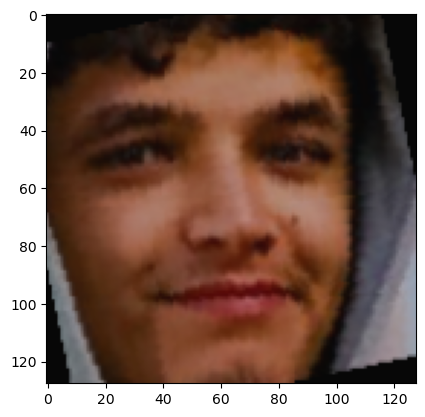

In [9]:
train_batch, label = next(iter(train_data_load))
plt.imshow(train_batch[0].permute(1, 2, 0))

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
class CNN_Model_V0(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            # nn.Dropout(0.5),
            nn.Linear(in_features=16*16*64, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(in_features=512, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(in_features=256, out_features=4)
        )

    def forward(self, x):
        return self.net(x)

model_0 = CNN_Model_V0().to(device)
model_0

CNN_Model_V0(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [12]:
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(params=model_0.parameters(), lr=0.0005)
# scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

In [13]:
def accuracy_fn(pred, truth):
    total = len(pred)
    correct = torch.eq(pred, truth).sum().item() 
    val = correct/total * 100
    return val


In [14]:
def train_step(model, 
              data_loader,
              loss_fn,
              opt,
              device, epoch):
    train_loss=0
    train_acc=0

    for (X, y) in data_loader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss+=loss
        train_acc += accuracy_fn(y_pred.argmax(dim=1), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        # scheduler.step()

    train_loss = train_loss/len(data_loader)
    train_acc /= len(data_loader)

    print(f"Epoch  {epoch} :   Train Loss = {train_loss} ----- Train Accuracy = {train_acc}%")


def test_step(model,
             data_loader,
             loss_fn,
             device, epoch):

    test_loss = 0
    test_acc=0
    
    with torch.inference_mode():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
    
            y_pred = model(X)
            loss=loss_fn(y_pred, y)
            test_acc += accuracy_fn(y_pred.argmax(dim=1), y)
            test_loss+=loss
            
    test_loss = test_loss/len(data_loader)
    test_acc /= len(data_loader)
    print(f"Epoch  {epoch} :   Test Loss = {test_loss} ----- Test Accuracy = {test_acc}%")

In [15]:
EPOCHS = 250

model_save_path = r"C:\Users\HP\Desktop\AI ML\PyTorch\F1\MODEL\\"

for epoch in range(EPOCHS):
    train_step(model_0, train_data_load, loss_fn, opt, device, epoch)

    test_step(model_0, test_data_load, loss_fn, device, epoch)
    print()
    if(epoch%15==0):
        model_path_curr = model_save_path + str(epoch) + ".pth"
        torch.save(obj=model_0.state_dict(), f=model_path_curr)

Epoch  0 :   Train Loss = 1.4117945432662964 ----- Train Accuracy = 42.317708333333336%
Epoch  0 :   Test Loss = 0.9198365211486816 ----- Test Accuracy = 66.66666666666667%

Epoch  1 :   Train Loss = 1.0478756427764893 ----- Train Accuracy = 51.692708333333336%
Epoch  1 :   Test Loss = 0.9340605139732361 ----- Test Accuracy = 59.02777777777777%

Epoch  2 :   Train Loss = 0.9685612916946411 ----- Train Accuracy = 60.28645833333333%
Epoch  2 :   Test Loss = 0.8457554578781128 ----- Test Accuracy = 65.97222222222221%

Epoch  3 :   Train Loss = 0.7703949213027954 ----- Train Accuracy = 67.1875%
Epoch  3 :   Test Loss = 0.6638953685760498 ----- Test Accuracy = 77.77777777777777%

Epoch  4 :   Train Loss = 0.7893922924995422 ----- Train Accuracy = 68.48958333333334%
Epoch  4 :   Test Loss = 0.5181666016578674 ----- Test Accuracy = 84.02777777777777%

Epoch  5 :   Train Loss = 0.6500547528266907 ----- Train Accuracy = 74.21874999999999%
Epoch  5 :   Test Loss = 0.486916184425354 ----- Test Ac

KeyboardInterrupt: 

In [16]:
load_model = CNN_Model_V0()
load_model.load_state_dict(torch.load(f=r"C:\Users\HP\Desktop\AI ML\PyTorch\F1\MODEL\15.pth"))

<All keys matched successfully>

In [26]:
test_batch, label = next(iter(test_data_load))

y_pred = load_model(test_batch)
y_pred = y_pred.argmax(dim=1)
y_pred

tensor([0, 1, 0, 0, 2, 0, 1, 0, 2, 2, 1, 1, 0, 0, 1, 3, 2, 0, 1, 1, 0, 1, 0, 0,
        2, 3, 1, 0, 1, 3, 1, 1, 2, 0, 3, 2, 1, 0, 0, 1, 3, 3, 1, 0, 0, 2, 0, 1])

Max


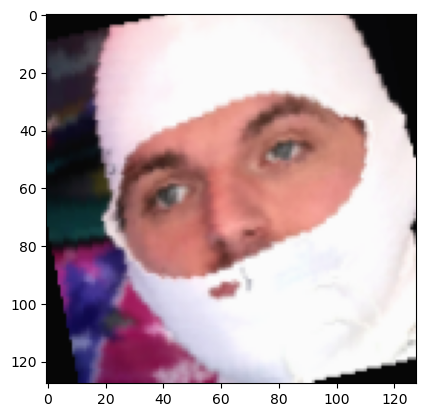

In [29]:
n = 25

img = test_batch[n]
plt.imshow(img.permute(1, 2, 0))

print(classes[y_pred[n]])

NameError: name 'y_pred' is not defined

tensor([0, 1, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 3, 3, 2, 0, 1, 1, 0, 1, 0, 0,
        2, 3, 1, 0, 1, 1, 1, 1, 2, 0, 3, 2, 1, 0, 1, 0, 0, 0, 1, 0, 3, 2, 0, 1])